## **LOAD MERGE DATA E-COMMERS**

In [1]:
import pandas as pd
import numpy as np

In [2]:
shopee    = pd.read_csv('data_shopee_clean.csv')
lazada    = pd.read_csv('data_lazada_clean.csv')
tokopedia = pd.read_csv('data_tokopedia_clean.csv')

In [3]:
# Jumlah data masing-masing e-commers
print(f"Jumlah Data Shopee: {shopee.shape[0]} baris, {shopee.shape[1]} kolom")
print(f"Jumlah Data Lazada: {lazada.shape[0]} baris, {lazada.shape[1]} kolom")
print(f"Jumlah Data Tokopedia: {tokopedia.shape[0]} baris, {tokopedia.shape[1]} kolom")

Jumlah Data Shopee: 1015 baris, 5 kolom
Jumlah Data Lazada: 3066 baris, 5 kolom
Jumlah Data Tokopedia: 577 baris, 5 kolom


In [4]:
# Persamaan nama kolom
print(f"Kolom: {shopee.columns.tolist()}")
print(f"Kolom: {lazada.columns.tolist()}")
print(f"Kolom: {tokopedia.columns.tolist()}")

Kolom: ['Produk', 'Harga_Produk', 'Produk_Terjual', 'Lokasi_Toko', 'E-Commerce']
Kolom: ['Produk', 'Harga_Produk', 'Produk_Terjual', 'Lokasi_Toko', 'E-Commerce']
Kolom: ['Produk', 'Harga_Produk', 'Produk_Terjual', 'Lokasi_Toko', 'E-Commerce']


## **MERGE DATA E-COMMERS**

In [5]:
data = pd.concat([shopee, lazada, tokopedia], ignore_index = True)
data['E-Commerce'] = data['E-Commerce'].str.strip().str.title()

In [6]:
data

,Produk,Harga_Produk,Produk_Terjual,Lokasi_Toko,E-Commerce
0,devilmimi realme C71 8GB+16GB / 128GB Handphon...,2139000.0,568.0,surabaya (kota),Shopee
1,Samsung Galaxy A07 4/64GB - Black,1599000.0,10000.0,surabaya (kota),Shopee
2,Samsung Galaxy A16 8/128GB - Black,2759000.0,10000.0,jakarta utara (kota),Shopee
3,HP IPHONE 14 128GB - Garansi Resmi Indonesia,9165000.0,13.0,surabaya (kota),Shopee
4,Infinix Hot 60i 6/128GB - Up to 12GB Extended ...,1799000.0,10000.0,jakarta utara (kota),Shopee
...,...,...,...,...,...
4653,Xiaomi Poco C71 4/128GB garansi resmi,1040000.0,23.0,surabaya (kota),Tokopedia
4654,[jikalaku] Nokia 105 (2023) NOKIA 105 LEDA,269500.0,2000.0,jakarta pusat (kota),Tokopedia
4655,HP Oprekan tanpa opsi pengembang,650000.0,80.0,magelang (kabupaten),Tokopedia
4656,Infinix Smart 9 4-128gb new,1200000.0,1.0,bandung (kota),Tokopedia


#### Informasi Data Merge

In [7]:
print(f"Jumlah Data: {data.shape[0]} baris, {data.shape[1]} kolom")

Jumlah Data: 4658 baris, 5 kolom


In [8]:
# Struktur data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4658 entries, 0 to 4657
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Produk          4658 non-null   object 
 1   Harga_Produk    4658 non-null   float64
 2   Produk_Terjual  4658 non-null   float64
 3   Lokasi_Toko     4658 non-null   object 
 4   E-Commerce      4658 non-null   object 
dtypes: float64(2), object(3)
memory usage: 182.1+ KB


In [9]:
# Pengecekan missing value
data.isnull().sum()

,0
Produk,0
Harga_Produk,0
Produk_Terjual,0
Lokasi_Toko,0
E-Commerce,0


In [10]:
# Pengecekan data duplikat
n_duplikat = data.duplicated().sum()
print(f"Data duplikat: {n_duplikat}")
data.drop_duplicates(inplace=True)

data.reset_index(drop = True, inplace = True)
print(f"Data duplikat setelah ditangani : {data.duplicated().sum()}")
print(f"Jumlah data bersih    : {data.shape[0]} baris")

Data duplikat: 225
Data duplikat setelah ditangani : 0
Jumlah data bersih    : 4433 baris


In [11]:
# Statistika deskriptif
data.describe()

,Harga_Produk,Produk_Terjual
count,4.433000e+03,4.433000e+03
mean,3.159726e+06,1.506097e+03
std,3.832430e+06,5.139531e+04
min,4.500000e+03,0.000000e+00
25%,1.245000e+06,0.000000e+00
50%,1.899000e+06,1.000000e+00
75%,3.599000e+06,6.300000e+01
max,3.925000e+07,3.380000e+06


## **KONSISTENSI DATA**

In [12]:
# Konsistensi per platform
for platform in data['E-Commerce'].unique():
    subset = data[data['E-Commerce'] == platform]
    print(f"\n{platform}")
    print(f"Jumlah baris       : {subset.shape[0]}")
    print(f"Harga median       : Rp {subset['Harga_Produk'].median():,.0f}")
    print(f"Harga min          : Rp {subset['Harga_Produk'].min():,.0f}")
    print(f"Harga max          : Rp {subset['Harga_Produk'].max():,.0f}")

    pct_terjual = (subset['Produk_Terjual'] > 0).sum() / len(subset) * 100
    print(f"Terjual median     : {subset['Produk_Terjual'].median():,.0f}")
    print(f"Data terjual (%)   : {pct_terjual:.1f}%")


Shopee
Jumlah baris       : 840
Harga median       : Rp 2,479,600
Harga min          : Rp 5,613
Harga max          : Rp 26,999,000
Terjual median     : 143
Data terjual (%)   : 98.5%

Lazada
Jumlah baris       : 3051
Harga median       : Rp 1,878,800
Harga min          : Rp 4,500
Harga max          : Rp 39,250,000
Terjual median     : 0
Data terjual (%)   : 29.3%

Tokopedia
Jumlah baris       : 542
Harga median       : Rp 1,573,500
Harga min          : Rp 115,000
Harga max          : Rp 24,039,000
Terjual median     : 30
Data terjual (%)   : 99.8%


## **PENANGANAN OUTLIER**

#### Harga Produk

In [13]:
# Analisis outlier harga produk
Q1  = data['Harga_Produk'].quantile(0.25)
Q3  = data['Harga_Produk'].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas  = Q3 + 1.5 * IQR

print(f"Q1             : Rp {Q1:,.0f}")
print(f"Q3             : Rp {Q3:,.0f}")
print(f"IQR            : Rp {IQR:,.0f}")
print(f"Batas bawah IQR: Rp {batas_bawah:,.0f}")
print(f"Batas atas IQR : Rp {batas_atas:,.0f}")

outlier = data[(data['Harga_Produk'] < batas_bawah) | (data['Harga_Produk'] > batas_atas)]
print(f"\nJumlah outlier    : {outlier.shape[0]} baris")
print(f"Persentase        : {outlier.shape[0]/len(data)*100:.1f}%")

Q1             : Rp 1,245,000
Q3             : Rp 3,599,000
IQR            : Rp 2,354,000
Batas bawah IQR: Rp -2,286,000
Batas atas IQR : Rp 7,130,000

Jumlah outlier    : 362 baris
Persentase        : 8.2%


In [14]:
# Penanganan outlier dengan clip agar data tidak hilang
HARGA_MIN = 100_000
HARGA_MAX = 25_000_000

sebelum_min = data['Harga_Produk'].min()
sebelum_max = data['Harga_Produk'].max()

data['Harga_Produk'] = data['Harga_Produk'].clip(lower = HARGA_MIN, upper = HARGA_MAX)

print("HASIL CLIP HARGA")
print(f"Sebelum clip - min: Rp {sebelum_min:,.0f}")
print(f"Sebelum clip - max: Rp {sebelum_max:,.0f}")
print(f"Setelah clip - min: Rp {data['Harga_Produk'].min():,.0f}")
print(f"Setelah clip - max: Rp {data['Harga_Produk'].max():,.0f}")
print(f"\nJumlah baris tetap: {data.shape[0]} (tidak ada yang hilang)")

HASIL CLIP HARGA
Sebelum clip - min: Rp 4,500
Sebelum clip - max: Rp 39,250,000
Setelah clip - min: Rp 100,000
Setelah clip - max: Rp 25,000,000

Jumlah baris tetap: 4433 (tidak ada yang hilang)


In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

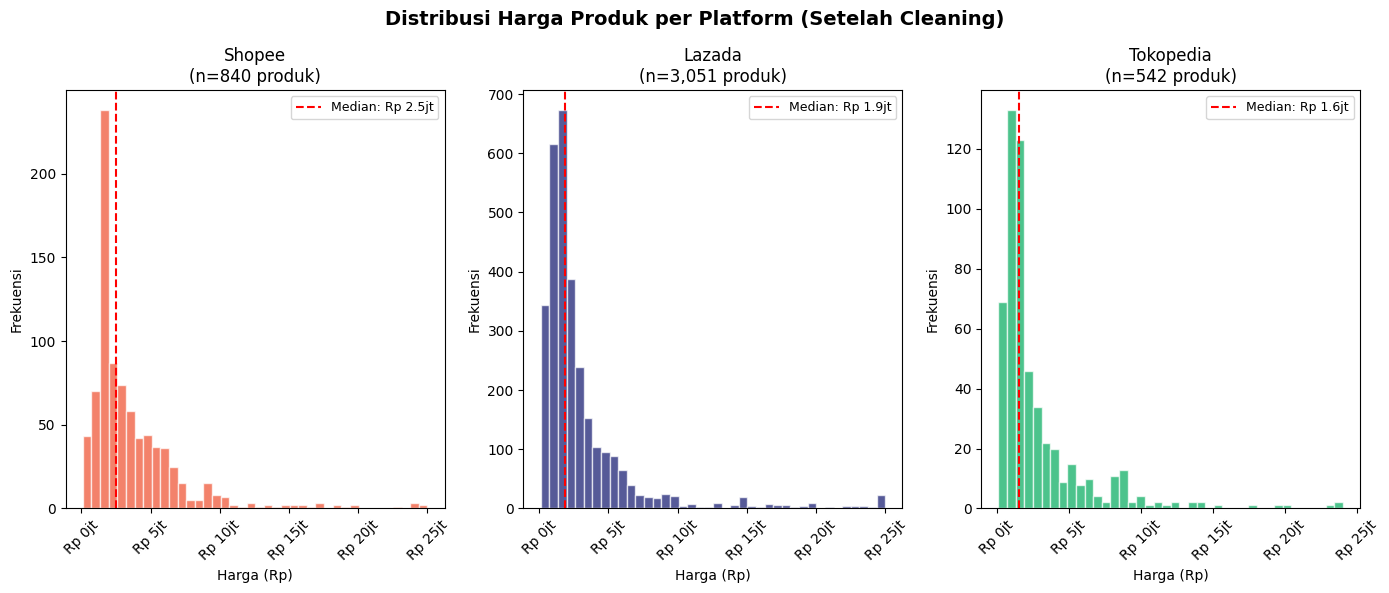

In [16]:
# Visualisasi distribusi harga produk
fig, axes = plt.subplots(1, 3, figsize = (14, 6))
fig.suptitle('Distribusi Harga Produk per Platform (Setelah Cleaning)',
             fontsize = 14, fontweight = 'bold')

colors = {'Shopee': '#ee4d2d', 'Lazada': '#0f146d', 'Tokopedia': '#00aa5b'}

for i, platform in enumerate(['Shopee', 'Lazada', 'Tokopedia']):
    subset = data[data['E-Commerce'] == platform]

    axes[i].hist(subset['Harga_Produk'], bins = 40,
                 color = colors[platform], alpha = 0.7, edgecolor = 'white')
    axes[i].set_title(f'{platform}\n(n={len(subset):,} produk)')
    axes[i].set_xlabel('Harga (Rp)')
    axes[i].set_ylabel('Frekuensi')
    axes[i].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'Rp {x/1_000_000:.0f}jt')
    )

    # Tambah garis median
    median = subset['Harga_Produk'].median()
    axes[i].axvline(median, color = 'red', linestyle = '--', linewidth = 1.5,
                    label = f'Median: Rp {median/1_000_000:.1f}jt')
    axes[i].legend(fontsize = 9)
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation = 45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_13737/2172996251.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes.boxplot(data_harga, labels = ['Shopee', 'Lazada', 'Tokopedia'],


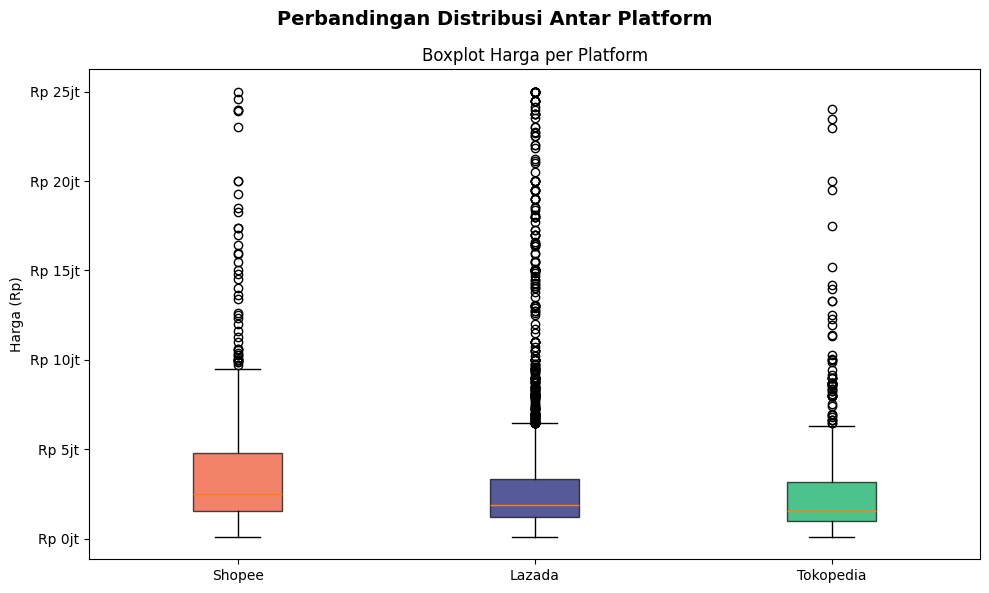

In [17]:
fig, axes = plt.subplots(1, 1, figsize = (10, 6))
fig.suptitle('Perbandingan Distribusi Antar Platform',
             fontsize = 14, fontweight = 'bold')

# Boxplot harga produk
data_harga = [data[data['E-Commerce'] == p]['Harga_Produk'].dropna()
              for p in ['Shopee', 'Lazada', 'Tokopedia']]
bp = axes.boxplot(data_harga, labels = ['Shopee', 'Lazada', 'Tokopedia'],
                       patch_artist = True, notch = False)
for patch, color in zip(bp['boxes'],
                         ['#ee4d2d', '#0f146d', '#00aa5b']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes.set_title('Boxplot Harga per Platform')
axes.set_ylabel('Harga (Rp)')
axes.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rp {x/1_000_000:.0f}jt')
)

plt.tight_layout()
plt.show()

#### Produk Terjual

In [18]:
# Outlier Produk_Terjual (hanya untuk data valid terjual)
mask_valid = data['Produk_Terjual'] > 0

Q1_t  = data.loc[mask_valid, 'Produk_Terjual'].quantile(0.25)
Q3_t  = data.loc[mask_valid, 'Produk_Terjual'].quantile(0.75)
IQR_t = Q3_t - Q1_t

batas_atas_terjual = Q3_t + 1.5 * IQR_t

print(f"Q1 Terjual       : {Q1_t:,.0f}")
print(f"Q3 Terjual       : {Q3_t:,.0f}")
print(f"Batas atas IQR   : {batas_atas_terjual:,.0f}")

outlier_terjual = data[mask_valid & (data['Produk_Terjual'] > batas_atas_terjual)]
print(f"Jumlah outlier   : {outlier_terjual.shape[0]} baris ({outlier_terjual.shape[0]/len(data)*100:.1f}%)")

# Clip (agar data tidak berkurang)
TERJUAL_MAX = data.loc[mask_valid, 'Produk_Terjual'].quantile(0.99)
data.loc[mask_valid, 'Produk_Terjual'] = data.loc[mask_valid, 'Produk_Terjual'].clip(upper=TERJUAL_MAX)

print(f"\nSetelah clip max terjual: {data['Produk_Terjual'].max():,.0f}")

Q1 Terjual       : 13
Q3 Terjual       : 262
Batas atas IQR   : 634
Jumlah outlier   : 364 baris (8.2%)

Setelah clip max terjual: 27,380


## **NORMALISASI TEKS**

In [19]:
# Brand familiar di Indonesia
brand_keywords = {
    'samsung'   : ['samsung', 'SAMSUNG', 'galaxy'],
    'apple'     : ['iphone', 'apple', 'ios','ip 4', 'ip 5', 'ip 6', 'ip 7', 'ip se',
                   'ip 8', 'ip x', 'ip 11', 'ip 12', 'ip 13', 'ip 14', 'ip 15',
                   'ip 16', 'ip 17', 'iphone pro max', 'pstore', 'IPHONE', 'iphone promax'],
    'huawei'    : ['huawei', 'HUAWEI'],
    'xiaomi'    : ['xiaomi', 'XIAOMI'],
    'redmi'     : ['redmi', 'REDMI'],
    'poco'      : ['poco', 'POCO'],
    'realme'    : ['realme', 'REALME'],
    'oppo'      : ['oppo', 'OPPO'],
    'vivo'      : ['vivo', 'VIVO', 'y17', 'y19', 'y91', 'y12'],
    'infinix'   : ['infinix', 'INFINIX'],
    'tecno'     : ['tecno', 'TECNO'],
    'itel'      : ['itel', 'ITEL'],
    'nokia'     : ['nokia', 'NOKIA'],
    'motorola'  : ['motorola', 'moto', 'MOTOROLA'],
    'asus'      : ['asus', 'zenfone', 'rog phone', 'ASUS'],
    'zte'       : ['zte', 'nubia', 'ZTE'],
    'iqoo'      : ['iqoo', 'iqo', 'IQOO'],
    'advan'     : ['advan', 'ADVAN'],
    'polytron'  : ['polytron', 'POLYTRON'],
    'evercoss' : ['evercoss', 'Evercoss', 'EVERCOSS', 'evercross', 'Evercross', 'EVERCROSS'],
    'sony' : ['sony', 'xperia']
}

In [20]:
# Keyword noise (produk bukan smartphone)
noise_keywords = ['printer', 'laptop', 'tablet', 'casing', 'charger',
                  'kabel', 'earphone', 'headset', 'powerbank', 'smartwatch']

In [21]:
# Lowercase, strip spasi berlebih, hapus karakter aneh
data['Produk_Clean'] = (
    data['Produk']
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)           # spasi ganda
    .str.replace(r'[^\w\s]', '', regex=True)        # hapus tanda baca
)

In [22]:
def ekstrak_brand(nama_produk_clean):
    # Filter noise
    for noise in noise_keywords:
        if noise in nama_produk_clean:
            return 'non_smartphone'

    # Cek whitelist brand
    for brand, keywords in brand_keywords.items():
        for kw in keywords:
            if kw in nama_produk_clean:
                return brand
    return 'other'  # tidak ketemu di whitelist

data['Brand_Ekstrak'] = data['Produk_Clean'].apply(ekstrak_brand)

In [23]:
print("Contoh hasil normalisasi:")
data[['Produk', 'Produk_Clean', 'Brand_Ekstrak']].head(10)

Contoh hasil normalisasi:


,Produk,Produk_Clean,Brand_Ekstrak
0,devilmimi realme C71 8GB+16GB / 128GB Handphon...,devilmimi realme c71 8gb16gb 128gb handphone ...,realme
1,Samsung Galaxy A07 4/64GB - Black,samsung galaxy a07 464gb black,samsung
2,Samsung Galaxy A16 8/128GB - Black,samsung galaxy a16 8128gb black,samsung
3,HP IPHONE 14 128GB - Garansi Resmi Indonesia,hp iphone 14 128gb garansi resmi indonesia,apple
4,Infinix Hot 60i 6/128GB - Up to 12GB Extended ...,infinix hot 60i 6128gb up to 12gb extended ra...,infinix
5,ITEL A100C 3+5GB RAM |/64GB ROM Smartphone 6.6...,itel a100c 35gb ram 64gb rom smartphone 66 inc...,itel
6,SAMSUNG GALAXY A56 5G 8/12GB 256GB,samsung galaxy a56 5g 812gb 256gb,samsung
7,iPhone 17 Pro 256GB Garansi Resmi Indonesia,iphone 17 pro 256gb garansi resmi indonesia,apple
8,Infinix Smart 20 4/64GB - Up to 8GB Extended R...,infinix smart 20 464gb up to 8gb extended ram...,infinix
9,SAMSUNG GALAXY A17 8GB 256GB | BLACK - BLUE - ...,samsung galaxy a17 8gb 256gb black blue grey,samsung


In [24]:
print(f"Jumlah unique brand (estimasi): {data['Brand_Ekstrak'].nunique()}")
print(f"Top 10 brand terbanyak:\n{data['Brand_Ekstrak'].value_counts()}")

Jumlah unique brand (estimasi): 22
Top 10 brand terbanyak:
Brand_Ekstrak
samsung           818
infinix           582
xiaomi            469
other             412
oppo              375
tecno             374
vivo              347
realme            297
apple             154
poco              121
redmi             112
itel              101
zte                86
nokia              65
motorola           36
advan              23
asus               20
iqoo               14
evercoss           13
huawei              8
sony                5
non_smartphone      1
Name: count, dtype: int64


In [25]:
# Lihat isi produk yang tidak terdeteksi brandnya
other_sample = data[data['Brand_Ekstrak'] == 'other'][['Produk', 'Produk_Clean']].reset_index(drop = True)

print(f"Total 'other': {len(other_sample)}")
print("\nSample 30 produk 'other':")
print(other_sample.head(30).to_string())

Total 'other': 412

Sample 30 produk 'other':
                                                                                                  Produk                                                                                          Produk_Clean
0                                       12 Pro 128gb/256gb/512gb Secondhand Like New Original Bergaransi                                        12 pro 128gb256gb512gb secondhand like new original bergaransi
1                                                        Ponsel mini sentuh ultra kecil Soyes XS 15 S 23                                                       ponsel mini sentuh ultra kecil soyes xs 15 s 23
2                                                                    Villaon V40S 4/64GB - Garansi Resmi                                                                     villaon v40s 464gb  garansi resmi
3                                    HP A31 RAM 8/256GB 4G LTE Second Mulus Fullset Garansi Toko 1 Tahun                      

In [26]:
# 1. Distribusi brand keseluruhan
print("Distribusi Brand_Ekstrak:")
print(data['Brand_Ekstrak'].value_counts())

# 2. Cek silang — brand yang rawan salah deteksi
checks = [
    ('apple',  'realme'),
    ('apple',  'oppo'),
    ('apple',  'samsung'),
    ('apple',  'infinix'),
    ('realme', 'samsung'),
]

print("\nValidasi silang brand:")
for brand_ekstrak, brand_asli in checks:
    salah = data[
        (data['Brand_Ekstrak'] == brand_ekstrak) &
        (data['Produk'].str.lower().str.contains(brand_asli))
    ]
    if len(salah) > 0:
        print(f"❌ {brand_asli} salah deteksi jadi {brand_ekstrak}: {len(salah)} baris")
        print(salah[['Produk', 'Brand_Ekstrak']].head(3))
    else:
        print(f"✅ Tidak ada {brand_asli} yang salah jadi {brand_ekstrak}")

# 3. Cek jumlah 'other' - berapa banyak dan contohnya
other = data[data['Brand_Ekstrak'] == 'other']
print(f"\nTotal 'other': {len(other)} baris ({len(other)/len(data)*100:.1f}%)")
print("\nSample 10 produk 'other':")
print(other[['Produk', 'Harga_Produk', 'E-Commerce']].head(10).to_string())

Distribusi Brand_Ekstrak:
Brand_Ekstrak
samsung           818
infinix           582
xiaomi            469
other             412
oppo              375
tecno             374
vivo              347
realme            297
apple             154
poco              121
redmi             112
itel              101
zte                86
nokia              65
motorola           36
advan              23
asus               20
iqoo               14
evercoss           13
huawei              8
sony                5
non_smartphone      1
Name: count, dtype: int64

Validasi silang brand:
✅ Tidak ada realme yang salah jadi apple
✅ Tidak ada oppo yang salah jadi apple
✅ Tidak ada samsung yang salah jadi apple
✅ Tidak ada infinix yang salah jadi apple
✅ Tidak ada samsung yang salah jadi realme

Total 'other': 412 baris (9.3%)

Sample 10 produk 'other':
                                                                                              Produk  Harga_Produk E-Commerce
173                              

## **SEGMENTASI**

In [27]:
bins_harga   = [0, 500_000, 2_000_000, 7_000_000, 25_000_000]
labels_harga = ['Budget', 'Mid-Range', 'Upper-Mid', 'Premium']

data['Segmen_Harga'] = pd.cut(
    data['Harga_Produk'],
    bins   = bins_harga,
    labels = labels_harga
)

print("Distribusi segmen harga:")
print(data['Segmen_Harga'].value_counts().sort_index())

print("\nDistribusi per platform:")
print(pd.crosstab(data['E-Commerce'], data['Segmen_Harga']))

Distribusi segmen harga:
Segmen_Harga
Budget        329
Mid-Range    2078
Upper-Mid    1662
Premium       364
Name: count, dtype: int64

Distribusi per platform:
Segmen_Harga  Budget  Mid-Range  Upper-Mid  Premium
E-Commerce                                         
Lazada           273       1424       1120      234
Shopee            24        346        389       81
Tokopedia         32        308        153       49


## **STRATIFIKASI VALID PRODUK TERJUAL**

In [28]:
# Flag untuk menandai produk yang punya data terjual valid
data['Valid_Terjual'] = data['Produk_Terjual'] > 0

print("Distribusi produk valid terjual per platform:\n")
for platform in data['E-Commerce'].unique():
    subset = data[data['E-Commerce'] == platform]
    punya = subset['Valid_Terjual'].sum()
    total = len(subset)
    print(f"{platform}: {punya}/{total} ({punya/total*100:.1f}%) memiliki data terjual")

Distribusi produk valid terjual per platform:

Shopee: 827/840 (98.5%) memiliki data terjual
Lazada: 895/3051 (29.3%) memiliki data terjual
Tokopedia: 541/542 (99.8%) memiliki data terjual


## Stratifikasi Data Final

In [29]:
# Subset 1: semua data (untuk analisis distribusi & harga)
data_all   = data.copy()

# Subset 2: hanya produk dengan data terjual valid (untuk analisis performa)
data_valid = data[data['Valid_Terjual'] == True].reset_index(drop=True)

print(f"data_all   : {data_all.shape[0]} baris [digunakan untuk analisis harga & distribusi platform]")
print(f"data_valid : {data_valid.shape[0]} baris [digunakan untuk analisis performa penjualan]\n")

print("Komposisi data_valid per platform:")
print(data_valid['E-Commerce'].value_counts())
print("\nKomposisi data_all per platform:")
print(data_all['E-Commerce'].value_counts())

data_all   : 4433 baris [digunakan untuk analisis harga & distribusi platform]
data_valid : 2263 baris [digunakan untuk analisis performa penjualan]

Komposisi data_valid per platform:
E-Commerce
Lazada       895
Shopee       827
Tokopedia    541
Name: count, dtype: int64

Komposisi data_all per platform:
E-Commerce
Lazada       3051
Shopee        840
Tokopedia     542
Name: count, dtype: int64


## **VALIDASI LOKASI TOKO**

In [30]:
data['Lokasi_Clean'] = (
    data['Lokasi_Toko']
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

print(f"Jumlah unique lokasi: {data['Lokasi_Clean'].nunique()}")
print(f"\nTop 15 lokasi terbanyak:")
data['Lokasi_Clean'].value_counts().head(15)

Jumlah unique lokasi: 137

Top 15 lokasi terbanyak:


,count
Lokasi_Clean,
jakarta barat (kota),755
surabaya (kota),557
jakarta utara (kota),392
jakarta pusat (kota),349
jakarta selatan (kota),314
bogor (kabupaten),172
cirebon (kabupaten),162
tangerang (kabupaten),156
tangerang (kota),148


## **PENYIMPANAN DATA FINAL**

In [31]:
data = data.drop(columns=['Produk_Clean', 'Lokasi_Clean'])
data.head()

,Produk,Harga_Produk,Produk_Terjual,Lokasi_Toko,E-Commerce,Brand_Ekstrak,Segmen_Harga,Valid_Terjual
0,devilmimi realme C71 8GB+16GB / 128GB Handphon...,2139000.0,568.0,surabaya (kota),Shopee,realme,Upper-Mid,True
1,Samsung Galaxy A07 4/64GB - Black,1599000.0,10000.0,surabaya (kota),Shopee,samsung,Mid-Range,True
2,Samsung Galaxy A16 8/128GB - Black,2759000.0,10000.0,jakarta utara (kota),Shopee,samsung,Upper-Mid,True
3,HP IPHONE 14 128GB - Garansi Resmi Indonesia,9165000.0,13.0,surabaya (kota),Shopee,apple,Premium,True
4,Infinix Hot 60i 6/128GB - Up to 12GB Extended ...,1799000.0,10000.0,jakarta utara (kota),Shopee,infinix,Mid-Range,True


In [32]:
# Tambahkan sebelum simpan CSV
print("RINGKASAN VERACITY\n")
print(f"Total baris setelah merge (sebelum dedup): {len(data) + n_duplikat}")
print(f"Duplikat dihapus                         : {n_duplikat}")
print(f"Total baris bersih                       : {len(data)}")
print(f"Missing value tersisa                    : {data.isnull().sum().sum()}")

RINGKASAN VERACITY

Total baris setelah merge (sebelum dedup): 4658
Duplikat dihapus                         : 225
Total baris bersih                       : 4433
Missing value tersisa                    : 0


In [33]:
data.to_csv('ecommerce_clean_merged.csv', index = False)
print("File berhasil disimpan: ecommerce_clean_merged.csv")

File berhasil disimpan: ecommerce_clean_merged.csv
